<a href="https://colab.research.google.com/github/AdityaInTech/Task-Modules/blob/main/Week_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore') # Hides unnecessary warnings

**Load Dataset and Print First 10 Rows**

In [10]:
# Cell 2: Load dataset directly from a public URL and print first 10 rows
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic_df = pd.read_csv(url)

# Display the first 10 rows
titanic_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


**Explore Basic Stats**

In [11]:
# Cell 3: Summarize basic stats
print("--- Dataset Info ---")
titanic_df.info()

print("\n--- Statistical Summary ---")
titanic_df.describe()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Statistical Summary ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Handle Missing Data (Mean/Median Imputation)**

In [12]:
# Cell 4: Check for missing data and fill them
print("Missing values before cleaning:\n", titanic_df.isnull().sum())

# Fill missing 'Age' using the Median
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)

# Fill missing 'Embarked' using the Mode (most frequent)
titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin' column as it has too many missing values to impute properly
titanic_df.drop(columns=['Cabin'], inplace=True)

print("\nMissing values after cleaning:\n", titanic_df.isnull().sum())

Missing values before cleaning:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**Encode Categorical Variables (Sex & Embarked)**

In [13]:
# Cell 5: Encoding categorical variables using LabelEncoder and OneHotEncoder

# 1. Label Encoding for 'Sex' (Transforms Male/Female to 1/0)
le = LabelEncoder()
titanic_df['Sex'] = le.fit_transform(titanic_df['Sex'])

# 2. One-Hot Encoding for 'Embarked' (Creates binary columns for C, Q, S)
ohe = OneHotEncoder(sparse_output=False, drop='first') # drop='first' prevents dummy variable trap
embarked_encoded = ohe.fit_transform(titanic_df[['Embarked']])

# Create a DataFrame for the new encoded columns and join it to the main dataset
embarked_df = pd.DataFrame(embarked_encoded, columns=ohe.get_feature_names_out(['Embarked']))
titanic_df = pd.concat([titanic_df.reset_index(drop=True), embarked_df.reset_index(drop=True)], axis=1)

# Drop the original 'Embarked' column as it's now encoded
titanic_df.drop(columns=['Embarked'], inplace=True)

titanic_df.head() # Show the updated dataframe

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0.0,1.0


**Visualize Age Distribution**

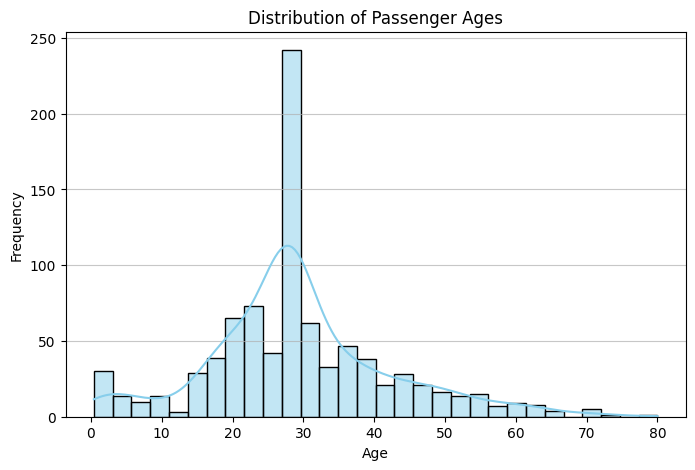

In [14]:
# Cell 6: Visualizing the distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(titanic_df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.7)
plt.show()

**Output Cleaned Dataset as a New CSV**

In [15]:
# Cell 7: Save the cleaned dataset
titanic_df.to_csv('cleaned_titanic.csv', index=False)
print("Cleaned dataset successfully saved as 'cleaned_titanic.csv'!")

Cleaned dataset successfully saved as 'cleaned_titanic.csv'!


**Practice Questions (Linear Regression & Train/Test Split)**

In [16]:
# Cell 8: Linear Regression Practice

# Create a simple mock dataset for House Prices vs Area
data = {
    'Area': [800, 1000, 1200, 1500, 1800, 2000, 2400, 2500, 3000, 3500],
    'Price': [150, 180, 210, 250, 300, 320, 380, 400, 480, 550] # Prices in thousands
}
house_df = pd.DataFrame(data)

# Define X (features) and y (target)
X = house_df[['Area']]
y = house_df['Price']

# Split dataset into train/test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Check Accuracy (using R-squared score)
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy (R-squared score): {accuracy * 100:.2f}%")

# Predict house price based on a new area input (e.g., 2200 sq ft)
new_area = [[2200]]
predicted_price = model.predict(new_area)
print(f"Predicted price for a {new_area[0][0]} sq ft house: ${predicted_price[0]:.2f}k")

Model Accuracy (R-squared score): 99.88%
Predicted price for a 2200 sq ft house: $355.02k
